In [ ]:
# === Setup ===
!pip install xgboost scikit-learn pandas numpy matplotlib nltk joblib --quiet
import os, re, joblib
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# download VADER nếu thiếu
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

print("Libraries imported successfully.")



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Libraries imported successfully.


In [3]:
# === Paths & Parameters ===
DATA_DIR = "data"             # thư mục chứa các file udemy_data_*.csv
OUTDIR = "artifacts_xgb"      # nơi lưu kết quả
TEST_SIZE = 0.2
RANDOM_STATE = 42
POS_TH, NEG_TH = 0.05, -0.05  # ngưỡng phân cực sentiment (VADER)
CALIBRATE = True

Path(OUTDIR).mkdir(parents=True, exist_ok=True)
print("Output folder created:", OUTDIR)


Output folder created: artifacts_xgb


In [6]:
# === Load & Concatenate CSVs ===
pattern = re.compile(r'udemy_data_.*\\.csv$', re.I)
paths = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.csv')]

assert paths, "Không tìm thấy file udemy_data_*.csv trong thư mục data/"

dfs = [pd.read_csv(p) for p in sorted(paths)]
df = pd.concat(dfs, ignore_index=True)
assert 'review_text' in df.columns, "Thiếu cột review_text"

print("Rows:", len(df), "| Columns:", list(df.columns))
df.head()


Rows: 16165 | Columns: ['source_file', 'course_url', 'course_slug', 'reviewer_name', 'review_text', 'rating_value', 'rating_scale', 'review_time_relative']


,source_file,course_url,course_slug,reviewer_name,review_text,rating_value,rating_scale,review_time_relative
0,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Avinash A.,"Fantastic course, covering all aspects of AI f...",5.0,5.0,1 week ago
1,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Gorun B.,"I loved it, Overall I would give it 4 because ...",4.0,5.0,2 weeks ago
2,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Pradeep Singh L.,An excellent course that provides valuable ins...,4.0,5.0,3 weeks ago
3,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Udemy User,There is so much information in this course. E...,5.0,5.0,3 weeks ago
4,udemy_data (1).xlsx,https://www.udemy.com/course/complete-ai-guide...,complete-ai-guide,Eduardo A.,I can confidently say it was an awesome course...,5.0,5.0,1 month ago


In [7]:
# === Tokenizer (keep negations) ===
def simple_tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.lower().replace("’", "'")
    tokens = re.findall(r"[a-z]+'?[a-z]+", text)
    tokens = [t for t in tokens if len(t) >= 2]
    stop = {
        'the','and','for','with','this','that','you','your','yours','our','ours',
        'to','in','of','on','it','is','are','was','were','be','been','am',
        'as','at','by','an','a','from','or','if','so','we','they','i','me','my',
        'course','section','module','video','lecture','udemy','instructor','teacher','classes','class'
    }
    return [t for t in tokens if t not in stop]

print(simple_tokenize("The course wasn't bad, not great either."))


["wasn't", 'bad', 'not', 'great', 'either']


In [8]:
# === Auto-label with VADER (+ rating fallback) ===
sia = SentimentIntensityAnalyzer()
comp = df['review_text'].fillna('').astype(str).map(lambda x: sia.polarity_scores(x)['compound'])

y = pd.Series(np.ones(len(df), dtype=int))  # neutral = 1
y[comp >= POS_TH] = 2
y[comp <= NEG_TH] = 0

if 'rating_value' in df.columns:
    r = pd.to_numeric(df['rating_value'], errors='coerce')
    mask_mid = comp.between(NEG_TH, POS_TH)
    y.loc[mask_mid & (r >= 4)] = 2
    y.loc[mask_mid & (r <= 2)] = 0

vc = y.value_counts().sort_index().to_dict()
print("Label counts (0=neg,1=neu,2=pos):", vc)

with open(os.path.join(OUTDIR, "labels_generated_summary.txt"), "w", encoding="utf-8") as f:
    f.write(f"Counts (0/1/2): {vc}\\n")


Label counts (0=neg,1=neu,2=pos): {0: 822, 1: 322, 2: 15021}


In [9]:
# === Train/Test Split ===
X = df['review_text'].fillna('').astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", len(X_train), "| Test size:", len(X_test))


Train size: 12932 | Test size: 3233


In [10]:
# === Class Weights (inverse frequency) ===
uniq, cnt = np.unique(y_train, return_counts=True)
total = len(y_train)
cw = {c: total / (len(uniq)*cnt[i]) for i, c in enumerate(uniq)}
sample_w = np.array([cw[int(v)] for v in y_train])
print("Class weights:", cw)


Class weights: {np.int64(0): np.float64(6.561136478944698), np.int64(1): np.float64(16.70801033591731), np.int64(2): np.float64(0.3587140439932318)}


In [11]:
# === TF-IDF + XGBoost + GridSearch ===
tfidf = TfidfVectorizer(
    ngram_range=(1,2), min_df=5, max_df=0.7,
    tokenizer=simple_tokenize, lowercase=False
)

xgb = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, reg_alpha=0.0,
    random_state=RANDOM_STATE, n_jobs=-1
)

pipe = Pipeline([('tfidf', tfidf), ('clf', xgb)])

param_grid = {
    'clf__n_estimators':[300,500,800],
    'clf__max_depth':[4,6,8],
    'clf__learning_rate':[0.03,0.05,0.1],
    'clf__subsample':[0.7,0.8,1.0],
    'clf__colsample_bytree':[0.7,0.8,1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(pipe, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1)
gs.fit(X_train, y_train, clf__sample_weight=sample_w)

best_est = gs.best_estimator_
print("Best params:", gs.best_params_)
print("CV best macro-F1:", gs.best_score_)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


c:\Users\quoct\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.1, 'clf__max_depth': 8, 'clf__n_estimators': 800, 'clf__subsample': 1.0}
CV best macro-F1: 0.5532795749347817


In [12]:
# === Calibration (isotonic) ===
final_model = best_est
if CALIBRATE:
    calibrator = CalibratedClassifierCV(best_est, method='isotonic', cv=3)
    calibrator.fit(X_train, y_train)
    final_model = calibrator
print("Calibration done:", CALIBRATE)


c:\Users\quoct\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\quoct\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\quoct\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Calibration done: True


In [13]:
# === Evaluation ===
y_prob = final_model.predict_proba(X_test)
y_pred = np.argmax(y_prob, axis=1)

rep = classification_report(y_test, y_pred, digits=3, target_names=['negative','neutral','positive'])
print(rep)
with open(os.path.join(OUTDIR, "xgb_classification_report.txt"), "w", encoding="utf-8") as f:
    f.write(rep)

# Confusion Matrix (normalized)
cm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(4.5,4))
im = plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (normalized)")
plt.colorbar(im, fraction=0.046, pad=0.04)
ticks = np.arange(3); labs = ['negative','neutral','positive']
plt.xticks(ticks, labs, rotation=45, ha='right'); plt.yticks(ticks, labs)
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{cm[i,j]:.2f}", ha='center', va='center')
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "xgb_confusion_matrix_norm.png"), dpi=160)
plt.close()

# ROC-AUC OvR (macro)
y_bin = label_binarize(y_test, classes=[0,1,2])
auc_macro = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
plt.figure(figsize=(5,3))
plt.title(f"ROC-AUC OvR (macro): {auc_macro:.3f}")
plt.plot([0,1],[0,1])
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "xgb_roc_ovr.png"), dpi=160)
plt.close()

# PR Curve (Negative class)
y_neg = (y_test==0).astype(int)
ap = average_precision_score(y_neg, y_prob[:,0])
p, r, _ = precision_recall_curve(y_neg, y_prob[:,0])
plt.figure(figsize=(5,3))
plt.step(r, p, where='post')
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"PR Curve (Negative) AP={ap:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "xgb_pr_negative.png"), dpi=160)
plt.close()

print("ROC-AUC macro:", auc_macro, "| AP (Negative):", ap)


              precision    recall  f1-score   support

    negative      0.676     0.430     0.526       165
     neutral      0.200     0.016     0.029        64
    positive      0.954     0.992     0.972      3004

    accuracy                          0.944      3233
   macro avg      0.610     0.479     0.509      3233
weighted avg      0.925     0.944     0.931      3233

ROC-AUC macro: 0.940021680192246 | AP (Negative): 0.6128923693084012


In [14]:
# === Feature Importance (top terms) ===
tfidf_step = best_est.named_steps['tfidf']
clf_step = best_est.named_steps['clf']
feats = tfidf_step.get_feature_names_out()
imps = clf_step.feature_importances_
order = np.argsort(imps)[::-1][:200]

imp_df = pd.DataFrame({'feature': feats[order], 'importance': imps[order]})
imp_df.to_csv(os.path.join(OUTDIR, "xgb_feature_importance_top_terms.csv"), index=False)
imp_df.head(10)


,feature,importance
0,great,0.013218
1,no,0.009144
2,questions not,0.008459
3,good,0.008288
4,amazing,0.007701
5,nice,0.007290
6,excellent,0.006993
7,applications,0.006849
8,dive deeper,0.006314
9,ai applications,0.005993


In [15]:
# === Save Final Model ===
joblib.dump(final_model, os.path.join(OUTDIR, "xgb_tfidf_calibrated.joblib"))
print("Model saved to", os.path.join(OUTDIR, "xgb_tfidf_calibrated.joblib"))


Model saved to artifacts_xgb\xgb_tfidf_calibrated.joblib


In [16]:
# Tự load model / dữ liệu nếu chưa có sẵn trong RAM
import os, joblib, pandas as pd, numpy as np, re
from sklearn.model_selection import train_test_split

DATA_DIR = DATA_DIR if 'DATA_DIR' in globals() else 'data'
OUTDIR = OUTDIR if 'OUTDIR' in globals() else 'artifacts_xgb'
TEST_SIZE = TEST_SIZE if 'TEST_SIZE' in globals() else 0.2
RANDOM_STATE = 42

# 1) Load model nếu chưa có final_model
if 'final_model' not in globals():
    model_path = os.path.join(OUTDIR, 'xgb_tfidf_calibrated.joblib')
    assert os.path.exists(model_path), f"Không thấy model ở {model_path}. Hãy train trước."
    final_model = joblib.load(model_path)

# 2) Load dữ liệu nếu chưa có X_test/y_test
if 'X_test' not in globals() or 'y_test' not in globals():
    pattern = re.compile(r'udemy_data_.*\.csv$', re.I)
    paths = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
    assert paths, "Không tìm thấy CSV trong data/."
    dfs = [pd.read_csv(p) for p in sorted(paths)]
    df_all = pd.concat(dfs, ignore_index=True)
    assert 'review_text' in df_all.columns, "Thiếu cột review_text"
    # Nếu bạn có cột nhãn đã gán sẵn thì dùng; còn không thì chạy lại block auto-label trước đó để tạo y
    if 'y' not in globals():
        raise RuntimeError("Chưa có y_test/y, bạn hãy chạy lại cell gán nhãn (VADER + rating) rồi split train/test.")


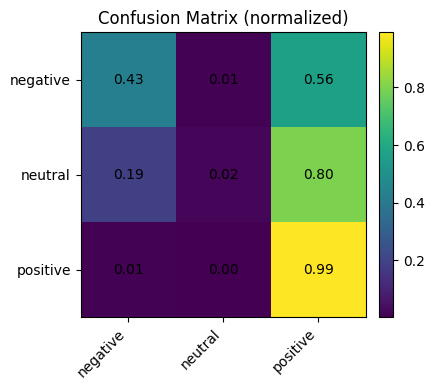

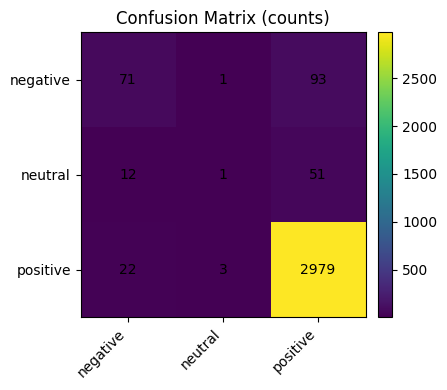

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

y_prob = final_model.predict_proba(X_test)
y_pred = np.argmax(y_prob, axis=1)

# normalized
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(4.5,4))
im = plt.imshow(cm_norm, interpolation='nearest')
plt.title("Confusion Matrix (normalized)")
plt.colorbar(im, fraction=0.046, pad=0.04)
labs = ['negative','neutral','positive']
ticks = np.arange(3)
plt.xticks(ticks, labs, rotation=45, ha='right'); plt.yticks(ticks, labs)
for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{cm_norm[i,j]:.2f}", ha='center', va='center')
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "xgb_confusion_matrix_norm.png"), dpi=160)
plt.show()

# counts
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5,4))
im = plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (counts)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks, labs, rotation=45, ha='right'); plt.yticks(ticks, labs)
for i in range(3):
    for j in range(3):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center')
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "xgb_confusion_matrix_counts.png"), dpi=160)
plt.show()


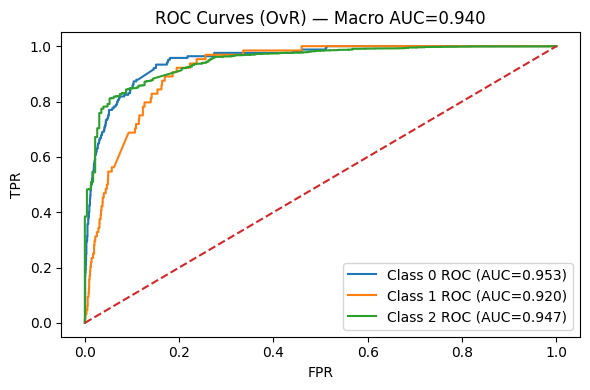

In [18]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

classes = [0,1,2]
y_bin = label_binarize(y_test, classes=classes)  # shape [n, 3]

fpr, tpr, roc_auc = {}, {}, {}
for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc[c] = auc(fpr[c], tpr[c])

macro_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')

plt.figure(figsize=(6,4))
for c in classes:
    plt.plot(fpr[c], tpr[c], label=f'Class {c} ROC (AUC={roc_auc[c]:.3f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title(f'ROC Curves (OvR) — Macro AUC={macro_auc:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "xgb_roc_ovr_full.png"), dpi=160)
plt.show()


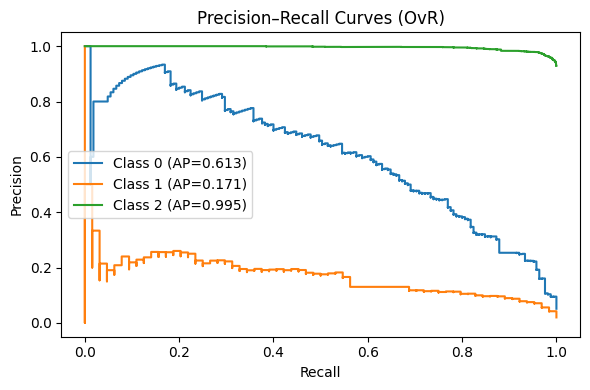

In [19]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

classes = [0,1,2]
y_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(6,4))
for i, c in enumerate(classes):
    p, r, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_bin[:, i], y_prob[:, i])
    plt.step(r, p, where='post', label=f'Class {c} (AP={ap:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision–Recall Curves (OvR)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "xgb_pr_ovr_full.png"), dpi=160)
plt.show()


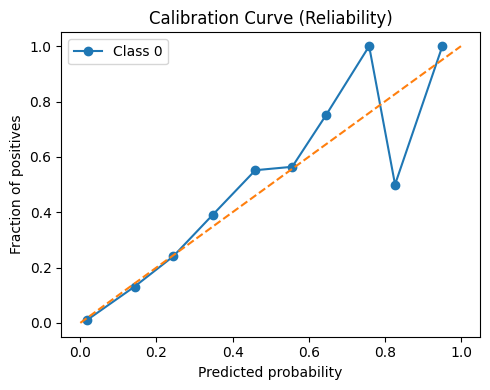

In [20]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Vẽ calibration cho từng lớp (chọn 0/1/2, ví dụ lớp 0=Negative)
pos_class = 0
prob_pos = y_prob[:, pos_class]
y_pos = (y_test == pos_class).astype(int)

frac_pos, mean_pred = calibration_curve(y_pos, prob_pos, n_bins=10, strategy='uniform')

plt.figure(figsize=(5,4))
plt.plot(mean_pred, frac_pos, marker='o', label=f'Class {pos_class}')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('Predicted probability'); plt.ylabel('Fraction of positives')
plt.title('Calibration Curve (Reliability)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, f"xgb_calibration_class{pos_class}.png"), dpi=160)
plt.show()


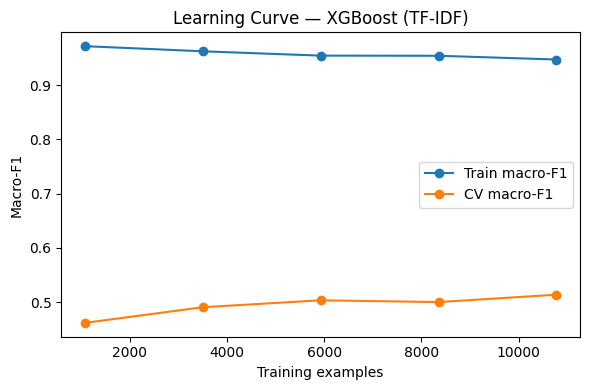

In [21]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, f1_score

# Dùng best_est (pipeline chưa calibrate) để vẽ learning curve cho nhanh
assert 'best_est' in globals(), "Cần biến best_est (pipeline đã tuned)."

train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_est,
    X=X, y=y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring=make_scorer(f1_score, average='macro'),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, marker='o', label='Train macro-F1')
plt.plot(train_sizes, valid_mean, marker='o', label='CV macro-F1')
plt.xlabel('Training examples'); plt.ylabel('Macro-F1')
plt.title('Learning Curve — XGBoost (TF-IDF)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "xgb_learning_curve.png"), dpi=160)
plt.show()


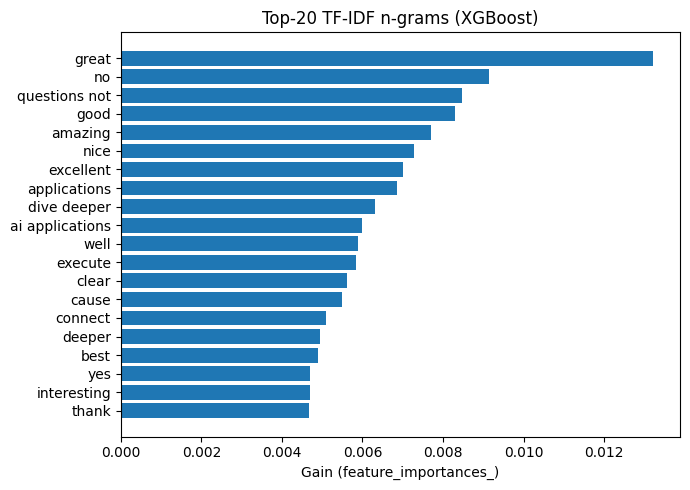

In [22]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

tfidf_step = best_est.named_steps['tfidf']
clf_step = best_est.named_steps['clf']
feat_names = tfidf_step.get_feature_names_out()
imps = clf_step.feature_importances_
order = np.argsort(imps)[::-1][:20]

top_feats = pd.DataFrame({'feature': feat_names[order], 'importance': imps[order]})

plt.figure(figsize=(7,5))
plt.barh(top_feats['feature'][::-1], top_feats['importance'][::-1])
plt.xlabel('Gain (feature_importances_)')
plt.title('Top-20 TF-IDF n-grams (XGBoost)')
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "xgb_feature_importance_top20.png"), dpi=160)
plt.show()

# Lưu full 200 nếu muốn
top200 = np.argsort(imps)[::-1][:200]
pd.DataFrame({'feature': feat_names[top200], 'importance': imps[top200]}).to_csv(
    os.path.join(OUTDIR, "xgb_feature_importance_top_terms.csv"), index=False
)
